# Spam Classification

## The Spam Dataset

### Downloading and Extracting the Dataset

In [1]:
import requests
import zipfile
import io

# URL of the dataset
url = "https://archive.ics.uci.edu/static/public/228/sms+spam+collection.zip"
# Download the dataset
response = requests.get(url)
if response.status_code == 200:
    print("Download successful")
else:
    print("Failed to download the dataset")

Download successful


In [2]:
# Extract the dataset
with zipfile.ZipFile(io.BytesIO(response.content)) as z:
    z.extractall("sms_spam_collection")
    print("Extraction successful")

Extraction successful


In [3]:
# Verify the extracted files
import os

# List the extracted files
extracted_files = os.listdir("sms_spam_collection")
print("Extracted files:", extracted_files)

Extracted files: ['.ipynb_checkpoints', 'readme', 'SMSSpamCollection']


### Loading the Dataset

In [4]:
import pandas as pd

# Load the dataset
df = pd.read_csv(
    "sms_spam_collection/SMSSpamCollection",
    sep="\t",
    header=None,
    names=["label", "message"],
)

In [5]:
# Display basic information about the dataset

print("-------------------- HEAD --------------------")
print(df.head())
print("-------------------- DESCRIBE --------------------")
print(df.describe())
print("-------------------- INFO --------------------")
print(df.info())

-------------------- HEAD --------------------
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...
-------------------- DESCRIBE --------------------
       label                 message
count   5572                    5572
unique     2                    5169
top      ham  Sorry, I'll call later
freq    4825                      30
-------------------- INFO --------------------
<class 'pandas.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   label    5572 non-null   str  
 1   message  5572 non-null   str  
dtypes: str(2)
memory usage: 542.9 KB
None


### Basic Sanity Checks

In [6]:
# Check for missing values
print("Missing values:\n", df.isnull().sum())

# Check for duplicates
print("Duplicate entries:", df.duplicated().sum())

Missing values:
 label      0
message    0
dtype: int64
Duplicate entries: 403


### Remove Any Duplicates

In [7]:
# Remove duplicates if any
df = df.drop_duplicates()

# Check for duplicates
print("Duplicate entries:", df.duplicated().sum())

Duplicate entries: 0


## Preprocessing the Spam Dataset
Preprocessing standardizes the text, reduces noise, and extracts meaningful features, all of which improve the performance of the Bayes spam classifier. The steps outlined here rely on the nltk library for tasks such as tokenization, stop word removal, and stemming.

### Downloading the Necessary Data Files

In [8]:
import nltk  # Natural Language Toolkit — Python's standard library for text processing

# Download the necessary NLTK data files (one-time setup; cached locally after first run)
nltk.download("punkt")        # Pre-trained tokenizer models for splitting text into words/sentences
nltk.download("punkt_tab")    # Newer table-based tokenizer data (required by NLTK 3.8.2+)
nltk.download("stopwords")    # List of common words (e.g., "the", "is", "and") to filter out as noise

# Print a header so we can visually compare the raw data against later preprocessing stages
print("=== BEFORE ANY PREPROCESSING ===")

# Display the first 5 rows of the dataframe to inspect the raw, unprocessed messages
print(df.head(5))

=== BEFORE ANY PREPROCESSING ===
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\moham\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


### Lowercasing the Text
Ensures that the classifier treats words equally, regardless of their original casing. By converting all characters to lowercase, the model considers "Free" and "free" as the same token, effectively reducing dimensionality and improving consistency. After this step, the dataset contains uniformly cased text.

In [9]:
# Convert all message text to lowercase
df["message"] = df["message"].str.lower()
print("\n=== AFTER LOWERCASING ===")
print(df["message"].head(5))


=== AFTER LOWERCASING ===
0    go until jurong point, crazy.. available only ...
1                        ok lar... joking wif u oni...
2    free entry in 2 a wkly comp to win fa cup fina...
3    u dun say so early hor... u c already then say...
4    nah i don't think he goes to usf, he lives aro...
Name: message, dtype: str


### Removing Punctuation and Numbers
Removing unnecessary punctuation and numbers simplifies the dataset by focusing on meaningful words. However, certain symbols such as $ and ! may contain important context in spam messages.

In [10]:
import re

# Remove non-essential punctuation and numbers, keep useful symbols like $ and !
df["message"] = df["message"].apply(lambda x: re.sub(r"[^a-z\s$!]", "", x))
print("\n=== AFTER REMOVING PUNCTUATION & NUMBERS (except $ and !) ===")
print(df["message"].head(5))


=== AFTER REMOVING PUNCTUATION & NUMBERS (except $ and !) ===
0    go until jurong point crazy available only in ...
1                              ok lar joking wif u oni
2    free entry in  a wkly comp to win fa cup final...
3          u dun say so early hor u c already then say
4    nah i dont think he goes to usf he lives aroun...
Name: message, dtype: str


### Tokenizing the Text
Tokenization divides the message text into individual words or tokens, a crucial step before further analysis. By converting unstructured text into a sequence of words, we prepare the data for operations like removing stop words and applying stemming. Each token corresponds to a meaningful unit, allowing downstream processes to operate on smaller, standardized elements rather than entire sentences.

In [11]:
from nltk.tokenize import word_tokenize

# Split each message into individual tokens
df["message"] = df["message"].apply(word_tokenize)
print("\n=== AFTER TOKENIZATION ===")
print(df["message"].head(5))


=== AFTER TOKENIZATION ===
0    [go, until, jurong, point, crazy, available, o...
1                       [ok, lar, joking, wif, u, oni]
2    [free, entry, in, a, wkly, comp, to, win, fa, ...
3    [u, dun, say, so, early, hor, u, c, already, t...
4    [nah, i, dont, think, he, goes, to, usf, he, l...
Name: message, dtype: object


### Removing Stop Words
Stop words are common words like and, the, or is that often do not add meaningful context. Removing them reduces noise and focuses the model on the words most likely to help distinguish spam from ham messages. 

In [12]:
from nltk.corpus import stopwords

# Define a set of English stop words and remove them from the tokens
stop_words = set(stopwords.words("english"))
df["message"] = df["message"].apply(lambda x: [word for word in x if word not in stop_words])
print("\n=== AFTER REMOVING STOP WORDS ===")
print(df["message"].head(5))


=== AFTER REMOVING STOP WORDS ===
0    [go, jurong, point, crazy, available, bugis, n...
1                       [ok, lar, joking, wif, u, oni]
2    [free, entry, wkly, comp, win, fa, cup, final,...
3        [u, dun, say, early, hor, u, c, already, say]
4    [nah, dont, think, goes, usf, lives, around, t...
Name: message, dtype: object


### Stemming
Stemming normalizes words by reducing them to their base form (e.g., running becomes run). This consolidates different forms of the same root word, effectively cutting the vocabulary size and smoothing out the text representation.

In [13]:
from nltk.stem import PorterStemmer

# Stem each token to reduce words to their base form
stemmer = PorterStemmer()
df["message"] = df["message"].apply(lambda x: [stemmer.stem(word) for word in x])
print("\n=== AFTER STEMMING ===")
print(df["message"].head(5))


=== AFTER STEMMING ===
0    [go, jurong, point, crazi, avail, bugi, n, gre...
1                         [ok, lar, joke, wif, u, oni]
2    [free, entri, wkli, comp, win, fa, cup, final,...
3        [u, dun, say, earli, hor, u, c, alreadi, say]
4    [nah, dont, think, goe, usf, live, around, tho...
Name: message, dtype: object


### Joining Tokens Back into a Single String
Rejoining tokens into space-separated strings restores the raw-text format that vectorizers like TF-IDF expect for the next phase.

In [14]:
# Rejoin tokens into a single string for feature extraction
df["message"] = df["message"].apply(lambda x: " ".join(x))
print("\n=== AFTER JOINING TOKENS BACK INTO STRINGS ===")
print(df["message"].head(5))


=== AFTER JOINING TOKENS BACK INTO STRINGS ===
0    go jurong point crazi avail bugi n great world...
1                                ok lar joke wif u oni
2    free entri wkli comp win fa cup final tkt st m...
3                  u dun say earli hor u c alreadi say
4            nah dont think goe usf live around though
Name: message, dtype: str


## Preprocessing Summary

Transformed raw SMS messages into a clean, vectorizer-ready format through a sequential NLP pipeline:

| Step | Purpose |
|------|---------|
| **Sanity checks** | Verified no missing values; removed 403 duplicate messages |
| **Lowercasing** | Collapsed case variants ("FREE"/"free") into single features |
| **Punctuation & number removal** | Stripped noise while preserving `$` and `!` as spam signals |
| **Tokenization** | Split each message into a list of individual words |
| **Stopword removal** | Dropped low-signal words ("the", "is", "to") using NLTK's English stopword list |
| **Stemming** | Applied Porter stemmer to collapse word variants ("joking" → "joke") |
| **Rejoining** | Converted token lists back to space-separated strings for vectorizer compatibility |

**Outcome:** Each message is now a normalized string of stemmed, content-bearing tokens — a compact feature representation ready for vectorization (TF-IDF/CountVectorizer) and Naive Bayes classification.

## Feature Extraction
`Feature extraction` transforms preprocessed SMS messages into numerical vectors suitable for machine learning algorithms. Since models cannot directly process raw text data, they rely on numeric representations—such as counts or frequencies of words—to identify patterns that differentiate spam from ham.
Bag-of-words represents each message as a vector of term counts over a vocabulary, with unigrams capturing word frequencies but no order. Adding bigrams recovers some local ordering (e.g., "free prize" vs. "free" alone), though global word order and sentence structure are still lost.

### Using CountVectorizer for the Bag-of-Words Approach


In [17]:
from sklearn.feature_extraction.text import CountVectorizer

# Create the vectorizer that turns text into word-count vectors:
#   ngram_range=(1, 2) -> use single words (unigrams) AND word pairs (bigrams)
#   min_df=1           -> keep a term only if it appears in at least 1 message (here, keep everything)
#   max_df=0.9         -> drop terms that appear in more than 90% of messages (too common to be useful)
vectorizer = CountVectorizer(min_df=1, max_df=0.9, ngram_range=(1, 2))

# Learn the vocabulary from the messages (fit), then convert each message
# into a row of word counts (transform). X is a sparse matrix: one row per
# message, one column per term in the vocabulary.
X = vectorizer.fit_transform(df["message"])

# Build the target variable: turn the text labels into numbers the model can use.
# "spam" becomes 1, everything else ("ham") becomes 0.
y = df["label"].apply(lambda x: 1 if x == "spam" else 0)

### How CountVectorizer Works
CountVectorizer tokenizes each message, filters the vocabulary by frequency thresholds (`min_df` / `max_df`), and converts documents into term-count vectors over a unigram + bigram vocabulary — producing the numerical matrix used for classification model training.

## Training and Evaluation (Spam Detection)
Multinomial Naive Bayes paired with a Pipeline ensures efficient text classification while preventing data leakage.

In [21]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline

# Chain the two steps into one object that runs them in order:
#   1. "vectorizer"  -> turns text into the count matrix (CountVectorizer from earlier)
#   2. "classifier"  -> trains Multinomial Naive Bayes on those counts
# Each step is a (name, object) pair; the name is a label you can reference later
# (e.g. when tuning settings with GridSearchCV).
# Key benefit: when you call .fit(), the vectorizer learns from the TRAINING data only,
# then the same transformation is applied automatically to any new data you predict on —
# which prevents data leakage.
pipeline = Pipeline([
    ("vectorizer", vectorizer),
    ("classifier", MultinomialNB())
])

### Hyperparameter Tuning
GridSearchCV systematically searches for the optimal alpha smoothing value in MultinomialNB, balancing bias and variance to improve model robustness and ensure better generalization on unseen data.

In [23]:
# Define the search space for hyperparameter tuning.
# The key uses "<step_name>__<parameter>" syntax to target a step inside the pipeline:
#   "classifier__alpha" = the `alpha` smoothing parameter of the MultinomialNB step.
# GridSearchCV will train a model for each value below and compare them.
# (alpha controls Laplace/Lidstone smoothing — how much weight to give words
#  the model hasn't seen; smaller = trusts the data more, larger = smooths more.)
param_grid = {
    "classifier__alpha": [0.01, 0.1, 0.15, 0.2, 0.25, 0.5, 0.75, 1.0]
}

# Set up the grid search:
#   pipeline    -> the vectorizer + classifier chain to tune
#   param_grid  -> the alpha values to try
#   cv=5        -> 5-fold cross-validation: split data into 5 parts, train on 4
#                  and validate on 1, rotating through all 5, then average the score.
#                  This gives a more reliable estimate than a single split.
#   scoring="f1"-> pick the best alpha by F1-score (balances precision & recall),
#                  which suits spam detection where classes are imbalanced.
grid_search = GridSearchCV(
    pipeline,
    param_grid,
    cv=5,
    scoring="f1"
)

# Run the search: for each alpha, cross-validate and record the average F1.
# Because the vectorizer lives inside the pipeline, each fold re-fits it on that
# fold's training portion only — so cross-validation stays leak-free.
grid_search.fit(df["message"], y)

# Pull out the best-performing pipeline (vectorizer + classifier, already refit
# on all the data using the winning alpha).
best_model = grid_search.best_estimator_
print("Best model parameters:", grid_search.best_params_)

Best model parameters: {'classifier__alpha': 0.25}


### F1 Score Preview
Alpha smoothing fixes Naive Bayes' zero-probability problem by adding a small constant to every word count, preventing unseen words from collapsing the entire classification product to zero, with larger alpha values providing more generous estimates for unseen words at the cost of pulling all probabilities slightly toward uniform distribution.

In [24]:
import pandas as pd

results = pd.DataFrame(grid_search.cv_results_)
print(results[["param_classifier__alpha", "mean_test_score", "std_test_score", "rank_test_score"]])

   param_classifier__alpha  mean_test_score  std_test_score  rank_test_score
0                     0.01         0.917449        0.007328                8
1                     0.10         0.924591        0.012962                6
2                     0.15         0.926721        0.012707                2
3                     0.20         0.926245        0.011018                3
4                     0.25         0.928415        0.010553                1
5                     0.50         0.925042        0.010712                4
6                     0.75         0.924562        0.008853                7
7                     1.00         0.925023        0.008937                5


### Evaluation
This is a confusion matrix — it shows how your spam classifier's predictions compare against the true labels on the evaluation data. Each cell counts messages that fall into one combination of (what it actually was) × (what the model guessed).

**How to read it**
Rows = the truth, columns = the model's prediction:

- Top-left, 889 — Ham messages correctly called Ham. ✓ (True Negatives)
- Top-right, 5 — Ham messages wrongly called Spam. ✗ (False Positives)
- Bottom-left, 0 — Spam messages wrongly called Ham. ✗ (False Negatives)
- Bottom-right, 140 — Spam messages correctly called Spam. ✓ (True Positives)

The diagonal (889 and 140) is correct predictions; the off-diagonal (5 and 0) is mistakes. Out of 1,034 messages, it got 1,029 right.
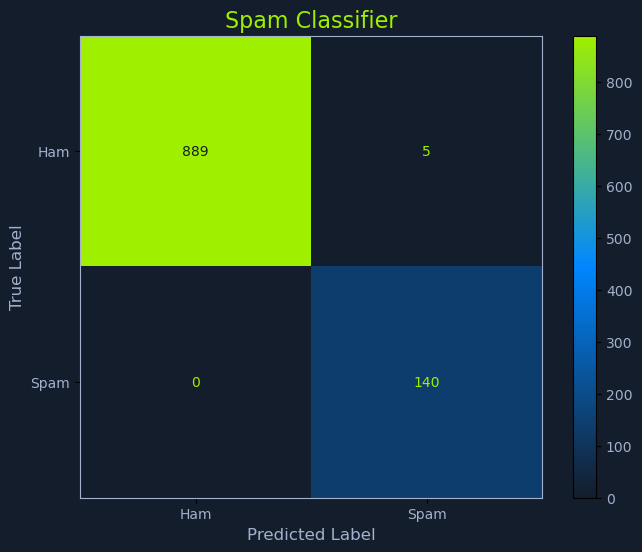

### Setting Up the Evaluation Messages
A diverse set of test SMS messages is provided, covering promotional offers, routine communications, urgent alerts, reminders, and incentive-based spam to evaluate real-world model performance.

In [25]:
# Example SMS messages for evaluation
new_messages = [
    "Congratulations! You've won a $1000 Walmart gift card. Go to http://bit.ly/1234 to claim now.",
    "Hey, are we still meeting up for lunch today?",
    "Urgent! Your account has been compromised. Verify your details here: www.fakebank.com/verify",
    "Reminder: Your appointment is scheduled for tomorrow at 10am.",
    "FREE entry in a weekly competition to win an iPad. Just text WIN to 80085 now!",
]

### Preprocessing New Messages
New messages are preprocessed using the same pipeline as training data — lowercasing, cleaning, tokenizing, removing stop words, and stemming — to ensure consistent input format for the model.

In [28]:
import numpy as np
import re

# Preprocess a single new message so it matches EXACTLY how the training data
# was cleaned. The model only understands text in the same shape it learned from,
# so any new input must go through the identical steps.
def preprocess_message(message):
    # 1. Lowercase: "FREE" and "free" should be the same feature.
    message = message.lower()

    # 2. Strip noise: remove anything that isn't a lowercase letter, whitespace,
    #    "$", or "!". Keeping $ and ! on purpose — they're spam signals.
    #    (regex: ^ inside [] means "not these"; \s = whitespace.)
    message = re.sub(r"[^a-z\s$!]", "", message)

    # 3. Tokenize: split the cleaned string into a list of individual words.
    tokens = word_tokenize(message)

    # 4. Drop stopwords: remove low-signal words ("the", "is", "to") using the
    #    same NLTK stopword list applied during training.
    tokens = [word for word in tokens if word not in stop_words]

    # 5. Stem: collapse word variants to a common root ("joking" -> "joke")
    #    with the same Porter stemmer used in training.
    tokens = [stemmer.stem(word) for word in tokens]

    # 6. Rejoin into a single space-separated string — the format the
    #    vectorizer inside the pipeline expects as input.
    return " ".join(tokens)

# Preprocess and vectorize messages
processed_messages = [preprocess_message(msg) for msg in new_messages]

### Vectorizing the Processed Messages
The pipeline's saved CountVectorizer transforms preprocessed text into a numerical feature matrix, ensuring the same vectorization scheme used during training is applied consistently to new messages.

In [30]:
# Transform preprocessed messages into feature vectors
X_new = best_model.named_steps["vectorizer"].transform(processed_messages)

### Making Predictions
The trained MultinomialNB classifier takes the vectorized messages and outputs both a predicted spam label and confidence probabilities for each classification decision.

In [37]:
# Run the vectorized messages through the trained Naive Bayes classifier.
#   .named_steps["classifier"] -> grabs the MultinomialNB step from the pipeline
#
# .predict()       -> returns the final label for each message: 1 (spam) or 0 (ham).
#                     The model picks whichever class it judges more probable.
predictions = best_model.named_steps["classifier"].predict(X_new)

# .predict_proba() -> returns the probabilities BEHIND each decision, as a pair
#                     [P(ham), P(spam)] per message (columns follow class order 0, 1).
#                     e.g. [0.02, 0.98] = 2% ham, 98% spam -> confident spam.
#                     This is the "confidence" — how sure the model is, not just the verdict.
prediction_probabilities = best_model.named_steps["classifier"].predict_proba(X_new)

### Displaying Predictions and Probabilities
For each message in the evaluation set, the output shows the original text alongside the predicted label (Spam or Not-Spam), the probability it is spam, and the probability it is not spam — giving a clear view of both the model's decision and its confidence behind that decision.

In [39]:
# Loop over the original messages and print each one with its verdict and confidence.
#   enumerate(new_messages) -> gives (i, msg): i is the position, msg is the text.
#                              We use i to pull the matching prediction/probabilities.
for i, msg in enumerate(new_messages):
    # Turn the numeric label (1/0) back into a readable word for display.
    prediction = "Spam" if predictions[i] == 1 else "Not-Spam"

    # predict_proba returned [P(ham), P(spam)] per message, so:
    #   index [1] = spam probability, index [0] = ham (not-spam) probability.
    spam_probability = prediction_probabilities[i][1]
    ham_probability = prediction_probabilities[i][0]

    # Print the message, the verdict, and both probabilities (.2f = 2 decimal places).
    print(f"Message: {msg}")
    print(f"Prediction: {prediction}")
    print(f"Spam Probability: {spam_probability:.2f}")
    print(f"Not-Spam Probability: {ham_probability:.2f}")
    print("-" * 50)  # separator line between messages for readability

Message: Congratulations! You've won a $1000 Walmart gift card. Go to http://bit.ly/1234 to claim now.
Prediction: Spam
Spam Probability: 1.00
Not-Spam Probability: 0.00
--------------------------------------------------
Message: Hey, are we still meeting up for lunch today?
Prediction: Not-Spam
Spam Probability: 0.00
Not-Spam Probability: 1.00
--------------------------------------------------
Message: Urgent! Your account has been compromised. Verify your details here: www.fakebank.com/verify
Prediction: Spam
Spam Probability: 0.96
Not-Spam Probability: 0.04
--------------------------------------------------
Message: Reminder: Your appointment is scheduled for tomorrow at 10am.
Prediction: Not-Spam
Spam Probability: 0.00
Not-Spam Probability: 1.00
--------------------------------------------------
Message: FREE entry in a weekly competition to win an iPad. Just text WIN to 80085 now!
Prediction: Spam
Spam Probability: 1.00
Not-Spam Probability: 0.00
----------------------------------

### Using joblib for Saving Models
Once a model performs well, it can be saved to disk using joblib — a Python library that efficiently serializes objects like scikit-learn pipelines by storing their full state, including learned parameters, so they can be reloaded later and used for predictions immediately without retraining, reducing computational cost and startup time in production environments.

In [40]:
import joblib

# Save the entire trained pipeline (vectorizer + classifier together) to disk
# so it can be reused later without retraining.
#   joblib.dump(object, filename) -> serializes the object to a file.
# joblib is preferred over plain pickle here because it handles the large NumPy
# arrays inside scikit-learn models more efficiently.
model_filename = 'spam_detection_model.joblib'
joblib.dump(best_model, model_filename)

print(f"Model saved to {model_filename}")

Model saved to spam_detection_model.joblib


### Reloading and Reusing the Saved Model
The trained model is saved as spam_detection_model.joblib using joblib, capturing everything needed for future predictions, and can later be reloaded into memory; when doing so, any new input data must go through the same preprocessing steps used during training to ensure consistent and accurate results.

In [49]:
new_messages = [
      # Spam
      "WIN NOW BIG WIN NOW",
      "lol wut? click this link to win",
      "URGENT: Your account will be suspended. Verify now: http://scam.biz/verify",
      "Congratulations! You've been selected for a $1000 gift card. Claim here!",
      "Make $5000/week working from home. No experience needed. Act NOW!",
      "You have 1 unread PRIZE notification. Click to collect your reward.",
      "FREE V1AGRA lowest prices guaranteed. Order online no prescription",
      "FINAL NOTICE: Your computer has a virus. Call 1-800-555-0199 immediately.",
      "Dear winner, your email won the UK lottery. Send SSN to claim.",
      "Hot singles in your area want to meet you tonight. Click here.",
      # Ham
      "Hey bro, what's up",
      "Can you pick up milk on your way home?",
      "Meeting rescheduled to 3pm — does that work for you?",
      "Thanks for dinner last night, it was great catching up!",
      "Your package has been delivered to the front door.",
      "Don't forget mom's birthday is this Saturday.",
      "I pushed the fix to the repo, can you review when you get a chance?",
      "Running 10 mins late, grab us a table?",
      "The quarterly report is attached. Let me know if you have questions.",
      "Hey, are we still on for the game tonight?",
]

# Load the saved model
loaded_model = joblib.load(model_filename)

# Preprocess new messages before prediction
new_data_processed = [preprocess_message(msg) for msg in new_messages]

# Make predictions on the preprocessed data
predictions = loaded_model.predict(new_data_processed)

# See verdict for each message
for msg, label in zip(new_messages, predictions):
    print(f"{'Spam' if label == 1 else 'Not-Spam'}: {msg}")

Spam: WIN NOW BIG WIN NOW
Not-Spam: lol wut? click this link to win
Spam: URGENT: Your account will be suspended. Verify now: http://scam.biz/verify
Spam: Congratulations! You've been selected for a $1000 gift card. Claim here!
Not-Spam: Make $5000/week working from home. No experience needed. Act NOW!
Spam: You have 1 unread PRIZE notification. Click to collect your reward.
Spam: FREE V1AGRA lowest prices guaranteed. Order online no prescription
Spam: FINAL NOTICE: Your computer has a virus. Call 1-800-555-0199 immediately.
Spam: Dear winner, your email won the UK lottery. Send SSN to claim.
Not-Spam: Hot singles in your area want to meet you tonight. Click here.
Not-Spam: Hey bro, what's up
Not-Spam: Can you pick up milk on your way home?
Not-Spam: Meeting rescheduled to 3pm — does that work for you?
Not-Spam: Thanks for dinner last night, it was great catching up!
Not-Spam: Your package has been delivered to the front door.
Not-Spam: Don't forget mom's birthday is this Saturday.
Not